# IF29 Twitter Analysis - Random Forest

## Imports and Data

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
import polars as pl


In [37]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [38]:
from src.ml.features import get_labeled_features

df = get_labeled_features("../../../data/processed/labeling_sample.csv").drop_nans("label")


## Features Engineering

In [39]:
df.head()

user_id,screen_name,name,followers_count,friends_count,listed_count,favourites_count,statuses_count,verified,default_profile,default_profile_image,created_at,last_tweet_at,first_seen_at,last_seen_at,profile_url,description,tweet_count,urls_per_tweet,hashtags_per_tweet,mentions_per_tweet,retweet_rate,reply_rate,unique_sources,bot_source_ratio,followers_friends_ratio,reputation,favourites_per_status,listed_per_follower,account_age_days,days_since_last_tweet,observation_span_days,tweet_frequency,tweets_per_day_in_dataset,description_length,has_description,has_url,has_location,screen_name_length,screen_name_has_digits,label
i64,str,str,i64,i64,i64,i64,i64,bool,bool,bool,datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,i64,"decimal[38,20]","decimal[38,20]","decimal[38,20]","decimal[38,20]","decimal[38,20]",i64,"decimal[38,20]",f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]","decimal[38,0]",f64,f64,i64,i64,i64,i64,i64,i64,i8
965652865447587840,"""LaMfeTr3MoA5Oqu""","""الحاج محمد عبد الرحمن 2""",852,116,4,48293,54733,false,true,false,2018-02-19 18:22:38,2018-06-17 16:21:22,2018-06-14 11:05:10,2018-06-17 16:21:22,null,"""‏‏مصري عروبي عاشق لمصر والامه …",37,0.43243243243243243243,4.08108108108108110000,1.10810810810810810000,1.00000000000000000000,0.00000000000000000000,1,0.00000000000000000000,7.344828,0.879257,0.882338,0.004695,117,0,3,0.316239,12.333333,101,1,0,1,15,1,1
1004414366777823232,"""richard30966081""","""richard""",62,49,2,2,2207,false,true,false,2018-06-06 17:27:00,2018-06-14 14:30:10,2018-06-14 14:30:10,2018-06-14 14:30:10,null,null,1,0.00000000000000000000,2.00000000000000000000,1.00000000000000000000,1.00000000000000000000,0.00000000000000000000,1,0.00000000000000000000,1.265306,0.553571,0.000906,0.032258,10,2,0,0.1,1.0,0,0,0,1,15,1,1
995510144317493248,"""Lidiane91013817""","""Alessandra ❤""",97,253,0,8937,9724,false,true,false,2018-05-13 03:44:48,2018-06-15 20:50:30,2018-06-15 20:50:30,2018-06-15 20:50:30,null,"""19 years... fan of @shawnmende…",1,0.00000000000000000000,0.00000000000000000000,1.00000000000000000000,1.00000000000000000000,0.00000000000000000000,1,0.00000000000000000000,0.383399,0.276353,0.919066,0.0,34,1,0,0.029412,1.0,56,1,0,1,15,1,1
927198378194296835,"""Letizialapizza1""","""ᴘᴀʀᴋ ᴍɪɴɪᴇ""",215,1032,1,64188,57055,false,true,false,2017-11-05 15:38:14,2018-06-17 12:58:23,2018-06-15 11:35:45,2018-06-17 12:58:23,null,null,3,1.00000000000000000000,1.66666666666666670000,1.33333333333333330000,1.00000000000000000000,0.00000000000000000000,1,0.00000000000000000000,0.208333,0.172276,1.12502,0.004651,223,0,2,0.013453,1.5,0,0,0,0,15,1,1
3317656799,"""RoxaMP""","""Roxy""",2363,3095,43,138804,246341,false,true,false,2015-06-10 17:43:11,2018-06-17 07:57:33,2018-06-14 14:50:46,2018-06-17 07:57:33,"""https://hstyles.co.uk/""","""I’m a harry_styles fan until t…",2,0.50000000000000000000,1.00000000000000000000,1.00000000000000000000,1.00000000000000000000,0.00000000000000000000,1,0.00000000000000000000,0.763489,0.432863,0.563463,0.018197,1102,0,2,0.001815,1.0,47,1,1,1,6,0,1


In [ ]:
drop_cols = [
    "user_id",
    "screen_name",
    "name",
    "created_at",
    "last_tweet_at",
    "first_seen_at",
    "last_seen_at",
    "profile_url",
    "description",
]

log_cols = [
    "followers_count",
    "friends_count",
    "listed_count",
    "favourites_count",
    "statuses_count",
    "tweet_count",
]

feature_cols = [c for c in df.columns if c not in drop_cols + ["label"]]
X = df.select(feature_cols)

X = X.with_columns(pl.col(pl.Boolean).cast(pl.Int8)).fill_null(0)

existing_log_cols = [c for c in log_cols if c in X.columns]
if existing_log_cols:
    X = X.with_columns(pl.col(existing_log_cols).log1p())
    

y = df["label"]

print(f"X: {X.shape}\ny: {y.shape}")


X: (420, 31)
y: (420,)


## Modelization

### Train-Test split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y.to_numpy()
)

In [42]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

param_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

rf = RandomForestClassifier(random_state=1)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train_np, y_train_np)

print("Best params:", grid.best_params_)
print("Best CV f1:", grid.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV f1: 0.846129394632827


### Evaluation (Test Set)

y_train balance:
 shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 278   │
│ 1     ┆ 58    │
└───────┴───────┘
y_test balance:
 shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 14    │
│ 0     ┆ 70    │
└───────┴───────┘
Test accuracy: 0.9166666666666666
Test precision: 0.6842105263157895
Test recall: 0.9285714285714286
Test f1: 0.7878787878787878


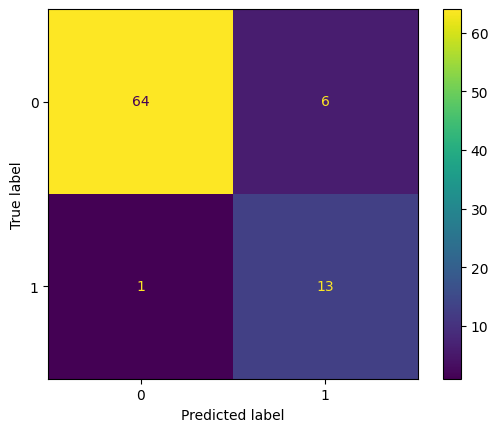

In [43]:
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

print("y_train balance:\n", y_train.value_counts())
print("y_test balance:\n", y_test.value_counts())

best_model = grid.best_estimator_
test_pred = best_model.predict(X_test_np)

print("Test accuracy:", accuracy_score(y_test_np, test_pred))
print("Test precision:", precision_score(y_test_np, test_pred))
print("Test recall:", recall_score(y_test_np, test_pred))
print("Test f1:", f1_score(y_test_np, test_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test_np, test_pred)).plot()

### Feature importance

Le Random Forest permet de garder une lecture assez directe des variables utilisées par le modèle. On peut donc regarder quelles features ont le plus contribué aux séparations des arbres, sans passer par une PCA qui mélangerait les variables entre elles.

In [ ]:
importance_df = pl.DataFrame(
    {
        "feature": X.columns,
        "importance": best_model.feature_importances_,
    }
).sort("importance", descending=True)

top_importances = importance_df.head(12)
top_importances

In [ ]:
plot_df = top_importances.sort("importance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["feature"].to_list(), plot_df["importance"].to_list(), color="#2563eb")
ax.set_title("Random Forest - top feature importances")
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

output_path = project_root / "docs/report/img/rf-feature-importance.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()